# LCR / Nyquist Plot

- `FOLDER_PATH`에 있는 모든 CSV 파일을 읽어서 plot합니다.
- `MODE = "CR"` 이면 `Resistance - Capacitance` 를 그립니다.
- `MODE = "Nyquist"` 이면 `Real Z - (-Imaginary Z)` 를 그립니다.
- 첫 번째 열의 frequency는 필터링용으로 사용합니다.
- `FREQ_MIN`, `FREQ_MAX`를 바꾸면 원하는 주파수 범위만 선택해서 그릴 수 있습니다.
- 축 단위는 값 크기에 맞춰 `n`, `u`, `m`, `k`, `M` 형식으로 자동 표기합니다.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

# ===== 사용자 설정 =====
# MODE는 "CR" 또는 "Nyquist" 중 하나로 설정하세요.
MODE = "Nyquist"

# CSV 파일들이 들어있는 폴더 경로를 넣으세요.
FOLDER_PATH = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\Zdeg_Nyquist"


# 주파수 범위(Hz). 전체를 쓰고 싶으면 None으로 두세요.
FREQ_MIN = 200
FREQ_MAX = 2_000000


선택한 폴더: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\Zdeg_Nyquist
CSV 파일 수: 29
주파수 범위: 200 Hz ~ 2000000 Hz


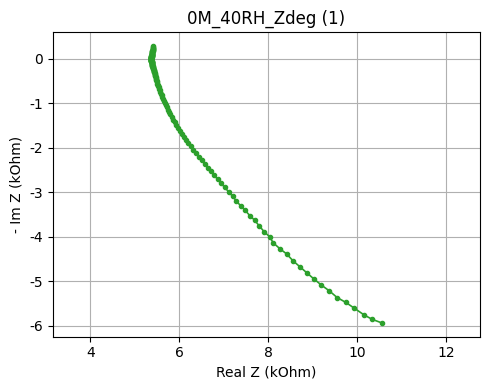

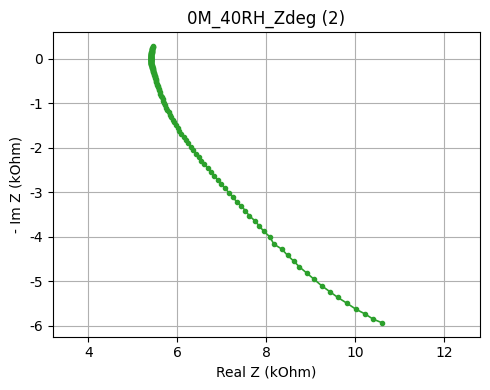

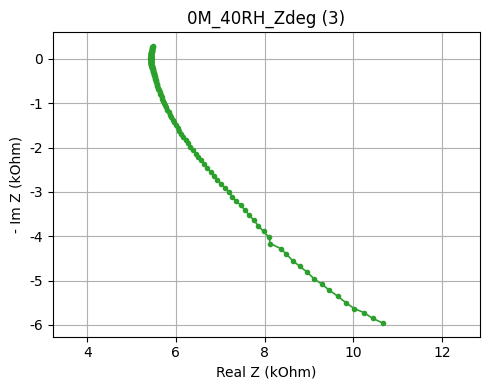

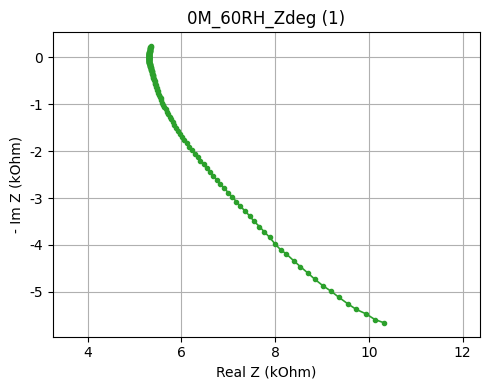

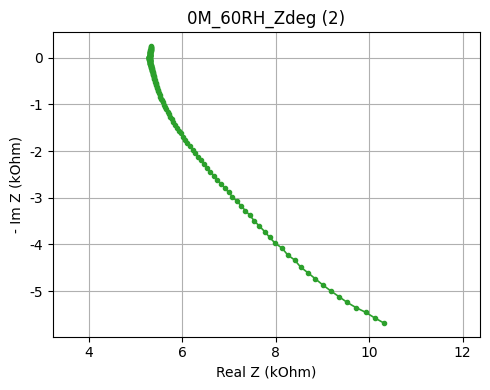

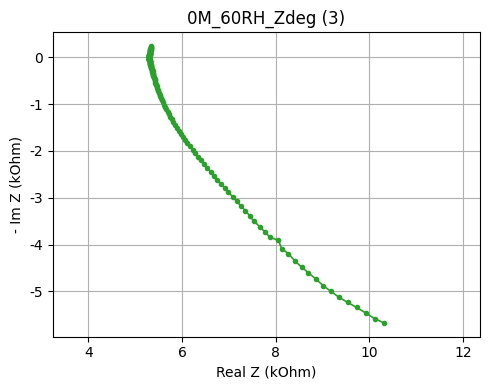

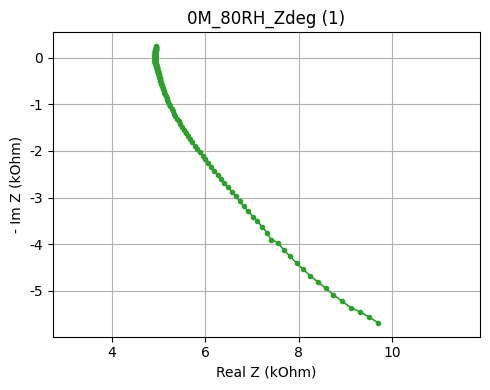

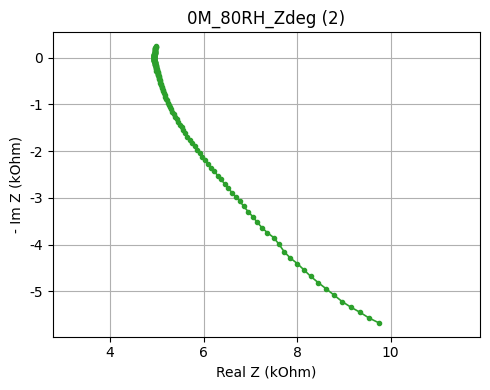

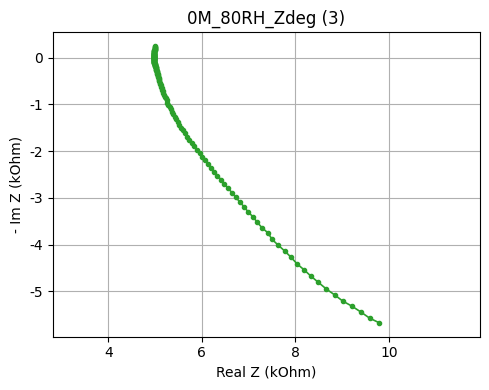

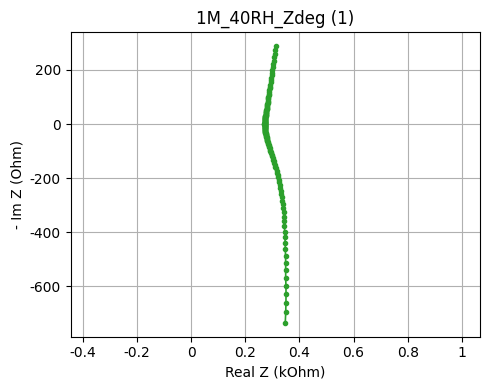

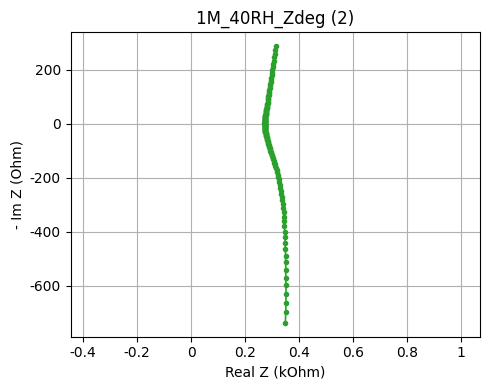

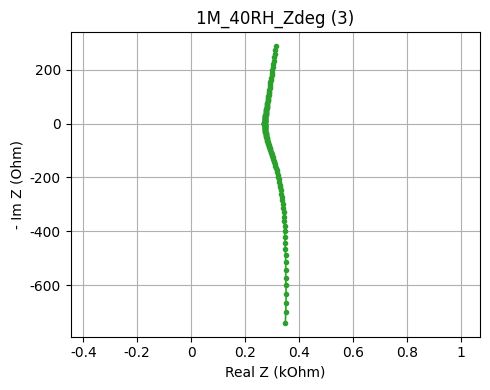

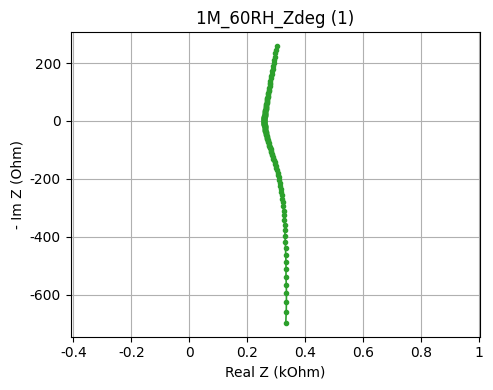

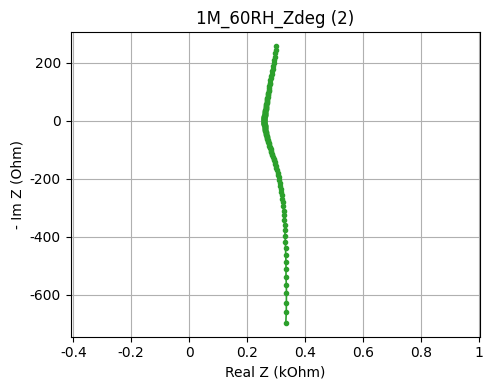

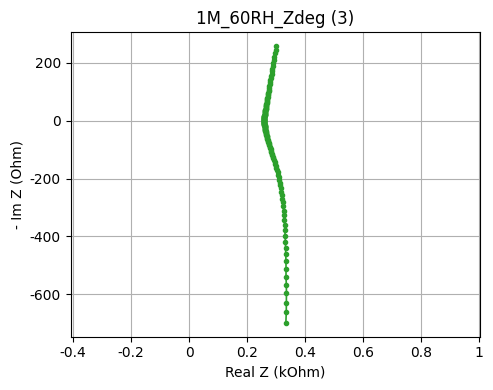

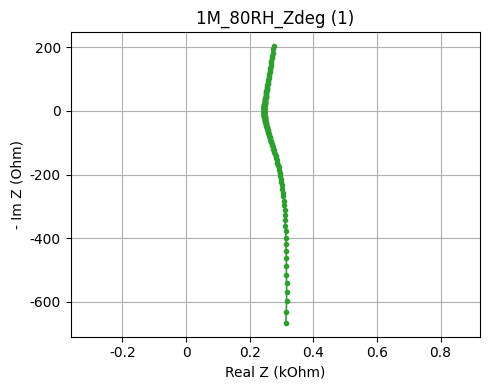

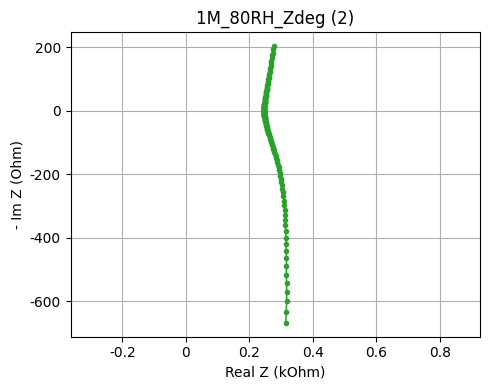

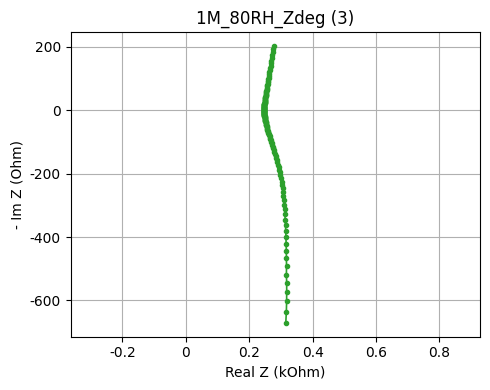

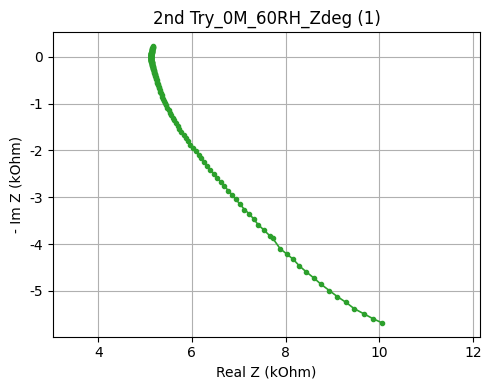

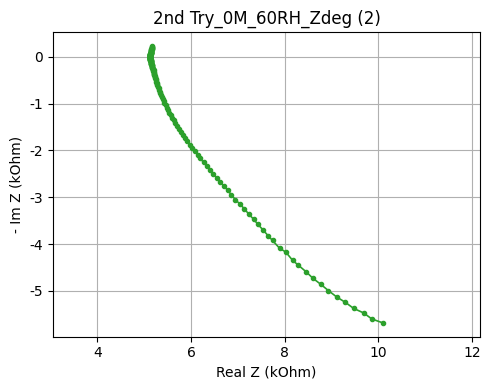

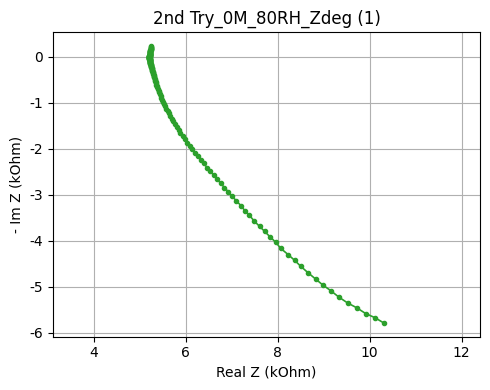

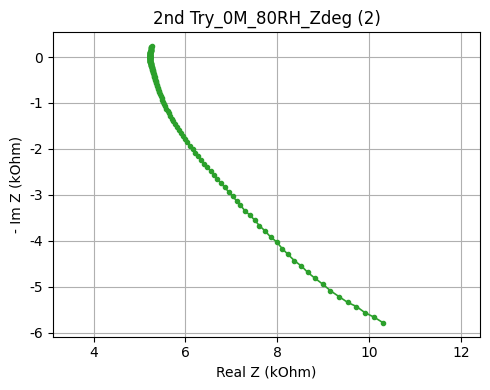

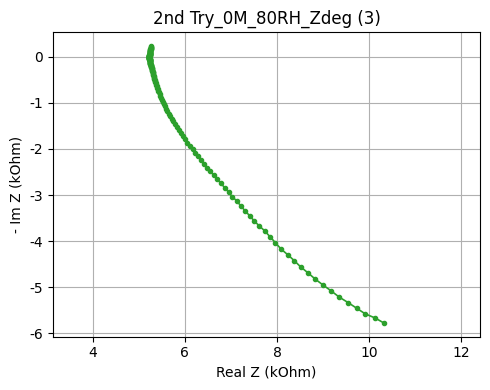

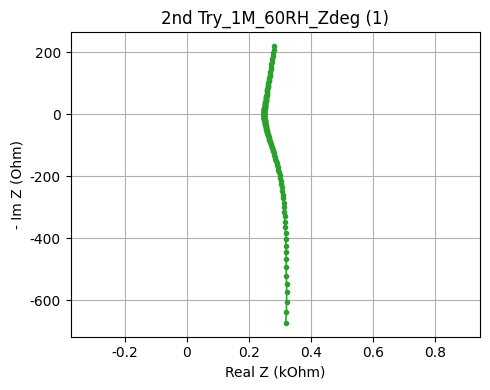

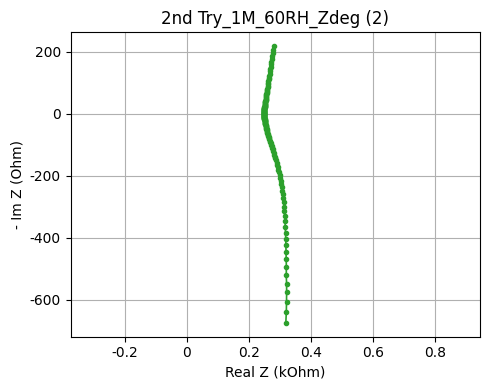

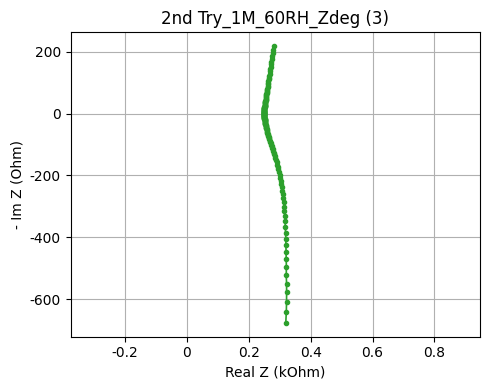

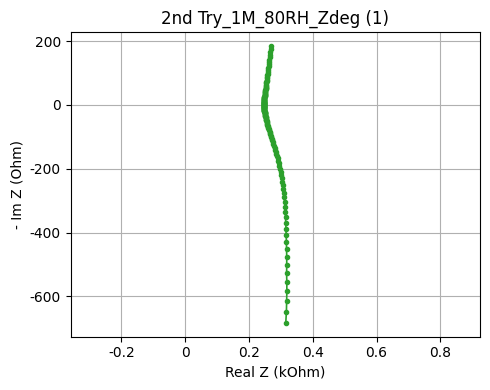

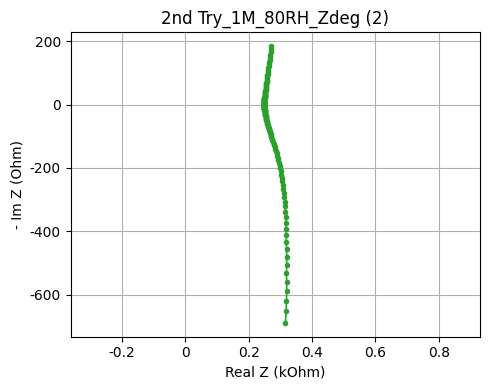

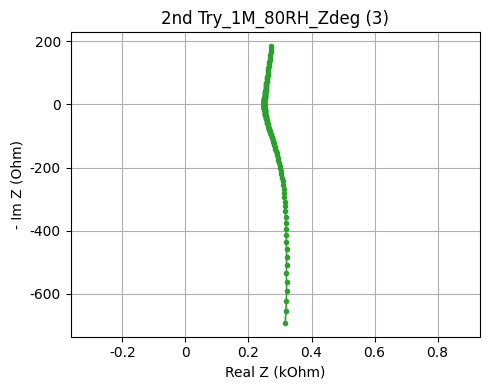

In [26]:
plt.rcParams["figure.figsize"] = (5, 4)
plt.rcParams["axes.grid"] = True

SI_PREFIXES = [
    (-12, "p"),
    (-9, "n"),
    (-6, "u"),
    (-3, "m"),
    (0, ""),
    (3, "k"),
    (6, "M"),
    (9, "G"),
]


def read_csv_three_columns(csv_path):
    df = pd.read_csv(csv_path, header=None)
    if df.shape[1] < 3:
        raise ValueError(f"CSV는 최소 3개 열이 필요합니다: {csv_path.name}")

    df = df.iloc[:, :3].copy()
    df.columns = ["frequency", "col2", "col3"]
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="any")

    if df.empty:
        raise ValueError(f"숫자로 해석 가능한 데이터가 없습니다: {csv_path.name}")

    return df


def filter_frequency_range(df, freq_min=None, freq_max=None):
    filtered = df.copy()

    if freq_min is not None:
        filtered = filtered[filtered["frequency"] >= freq_min]

    if freq_max is not None:
        filtered = filtered[filtered["frequency"] <= freq_max]

    if filtered.empty:
        raise ValueError("설정한 주파수 범위에 해당하는 데이터가 없습니다.")

    return filtered


def pick_scale(values):
    series = pd.Series(values).dropna()
    series = series[series != 0]
    if series.empty:
        return 1.0, ""

    reference = series.abs().median()
    for exponent, prefix in reversed(SI_PREFIXES):
        scale = 10 ** exponent
        scaled = reference / scale
        if 0.1 <= scaled < 1000:
            return scale, prefix

    exponent, prefix = SI_PREFIXES[0] if reference < 1 else SI_PREFIXES[-1]
    return 10 ** exponent, prefix


def make_formatter(scale):
    return FuncFormatter(lambda value, _: f"{value / scale:g}")


def format_axis(ax, axis, values, unit):
    scale, prefix = pick_scale(values)
    formatter = make_formatter(scale)
    label = f"{prefix}{unit}".strip()

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)

    return label


def plot_cr(csv_files, freq_min=None, freq_max=None):
    for csv_path in csv_files:
        df = read_csv_three_columns(csv_path)
        df = filter_frequency_range(df, freq_min=freq_min, freq_max=freq_max)
        resistance = df["col3"]
        capacitance = df["col2"]

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(resistance, capacitance, marker="o", markersize=3, linewidth=1.2, color="tab:blue")

        x_unit = format_axis(ax, "x", resistance, "Ohm")
        y_unit = format_axis(ax, "y", capacitance, "F")

        ax.set_xlabel(f"Resistance ({x_unit})")
        ax.set_ylabel(f"Capacitance ({y_unit})")
        ax.set_title(csv_path.stem)
        fig.tight_layout()
        plt.show()


def plot_nyquist(csv_files, freq_min=None, freq_max=None):
    for csv_path in csv_files:
        df = read_csv_three_columns(csv_path)
        df = filter_frequency_range(df, freq_min=freq_min, freq_max=freq_max)
        real_z = df["col2"]
        neg_imag_z = df["col3"]

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(real_z, neg_imag_z, marker="o", markersize=3, linewidth=1.2, color="tab:green")

        x_unit = format_axis(ax, "x", real_z, "Ohm")
        y_unit = format_axis(ax, "y", neg_imag_z, "Ohm")

        ax.set_xlabel(f"Real Z ({x_unit})")
        ax.set_ylabel(f"- Im Z ({y_unit})")
        ax.set_title(csv_path.stem)
        ax.set_aspect("equal", adjustable="datalim")
        fig.tight_layout()
        plt.show()


folder_path = Path(FOLDER_PATH)

if not str(folder_path).strip():
    raise ValueError("FOLDER_PATH를 입력하세요.")

if not folder_path.exists():
    raise FileNotFoundError(f"폴더를 찾을 수 없습니다: {folder_path}")

if FREQ_MIN is not None and FREQ_MAX is not None and FREQ_MIN > FREQ_MAX:
    raise ValueError("FREQ_MIN은 FREQ_MAX보다 클 수 없습니다.")

csv_files = sorted(folder_path.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"선택한 폴더에 CSV 파일이 없습니다: {folder_path}")

print(f"선택한 폴더: {folder_path}")
print(f"CSV 파일 수: {len(csv_files)}")
print(f"주파수 범위: {FREQ_MIN} Hz ~ {FREQ_MAX} Hz")

mode = MODE.strip().lower()
if mode == "cr":
    plot_cr(csv_files, freq_min=FREQ_MIN, freq_max=FREQ_MAX)
elif mode == "nyquist":
    plot_nyquist(csv_files, freq_min=FREQ_MIN, freq_max=FREQ_MAX)
else:
    raise ValueError('MODE는 "CR" 또는 "Nyquist" 이어야 합니다.')
